## Introduction

Name : Nicholas Calvin
 
Data Analyst working on a project to resolve a client's business problems. The client requires a data analysis report using statistical methods and an interactive visualization dashboard to assist in data-driven decision-making.

**SMART Framework and Problem Statements**

1. *Specific*: Enhance and equalize sales distribution across product categories, regions, and payment methods.
2. *Measurable*: The equalization and enhancement of sales will help achieve a revenue increase of more than 1% compared to the previous period.
3. *Achievable*: Optimize strategies to improve performance in lagging payment types and untapped regional markets.
4. *Relevant*: By optimizing strategies, the significant disparities found in the category, region, and payment method columns will be reduced.
5. *Time-bound*: Targets must be achieved within 1 year, aligned with the 1-year data analysis timeframe.

**Problem Statements**

*The objective is to assist in sales equalization across categories, regions, and payment methods, targeting a revenue increase of over 1% in the upcoming year. This will be achieved by optimizing strategies in underperforming payment segments and untapped regions.*

**Problem Analysis (5W+1H Method)**
1. What is the root cause of the performance disparity between regions, payment methods, and categories?
2. Where are the columns with the most significant data disparity located?
3. When did the uneven sales distribution occur?
4. How did the disparity in performance between regions, payment methods, and categories emerge?

**Dataset Description**

This dataset provides a comprehensive overview of online sales transactions across various product categories. Each row represents a single transaction accompanied by detailed information such as `transaction ID`, `date`, `category`, `product name`, `units sold`, `unit price`, `revenue`, `region`, and `payment method`.

**Data Link**

https://www.kaggle.com/datasets/shreyanshverma27/online-sales-dataset-popular-marketplace-data?resource=download

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from scipy.stats import chi2_contingency

**Data Loading**

In [2]:
pd.read_csv('P0M1_nicholas_calvin.csv')
df = pd.read_csv('P0M1_nicholas_calvin.csv')
print(df.info())
df

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 240 entries, 0 to 239
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Transaction ID    240 non-null    int64  
 1   Date              240 non-null    object 
 2   Product Category  240 non-null    object 
 3   Product Name      240 non-null    object 
 4   Units Sold        240 non-null    int64  
 5   Unit Price        240 non-null    float64
 6   Total Revenue     240 non-null    float64
 7   Region            240 non-null    object 
 8   Payment Method    240 non-null    object 
dtypes: float64(2), int64(2), object(5)
memory usage: 17.0+ KB
None


,Transaction ID,Date,Product Category,Product Name,Units Sold,Unit Price,Total Revenue,Region,Payment Method
0,10001,2024-01-01,Electronics,iPhone 14 Pro,2,999.99,1999.98,North America,Credit Card
1,10002,2024-01-02,Home Appliances,Dyson V11 Vacuum,1,499.99,499.99,Europe,PayPal
2,10003,2024-01-03,Clothing,Levi's 501 Jeans,3,69.99,209.97,Asia,Debit Card
3,10004,2024-01-04,Books,The Da Vinci Code,4,15.99,63.96,North America,Credit Card
4,10005,2024-01-05,Beauty Products,Neutrogena Skincare Set,1,89.99,89.99,Europe,PayPal
...,...,...,...,...,...,...,...,...,...
235,10236,2024-08-23,Home Appliances,Nespresso Vertuo Next Coffee and Espresso Maker,1,159.99,159.99,Europe,PayPal
236,10237,2024-08-24,Clothing,Nike Air Force 1 Sneakers,3,90.00,270.00,Asia,Debit Card
237,10238,2024-08-25,Books,The Handmaid's Tale by Margaret Atwood,3,10.99,32.97,North America,Credit Card
238,10239,2024-08-26,Beauty Products,Sunday Riley Luna Sleeping Night Oil,1,55.00,55.00,Europe,PayPal


Change the `date` column with object data type to datetime data type

In [3]:
df['Date'] = pd.to_datetime(df['Date'])

No data cleaning is required because:
1. There are no missing values.
2. The columns `unit price`, `total revenue`, and `units sold` are already numeric.
3. There is no duplicate data.

**Data Visualization**

Text(0.5, 1.0, 'Total Sales per Region')

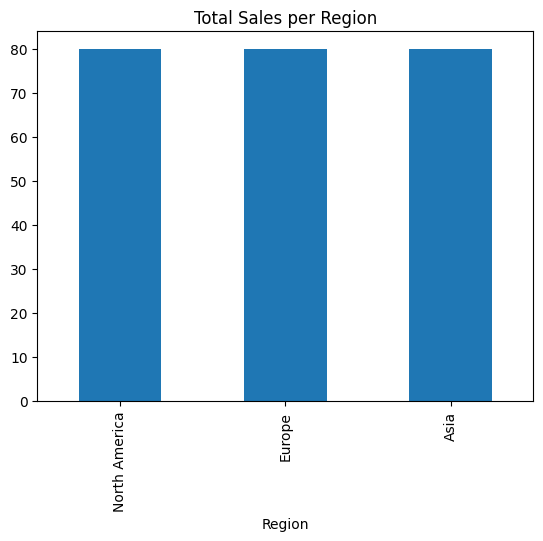

In [4]:
fig, ax = plt.subplots()
transaction = df["Region"].value_counts()
transaction.plot(kind="bar")
ax.set_title("Total Sales per Region")

The "Number of Sales per Region" diagram shows that the three regions in the data, namely North America, Europe, and Asia, each have exactly the same number of transactions, namely 80 transactions.

Text(0.5, 1.0, 'Monthly Income')

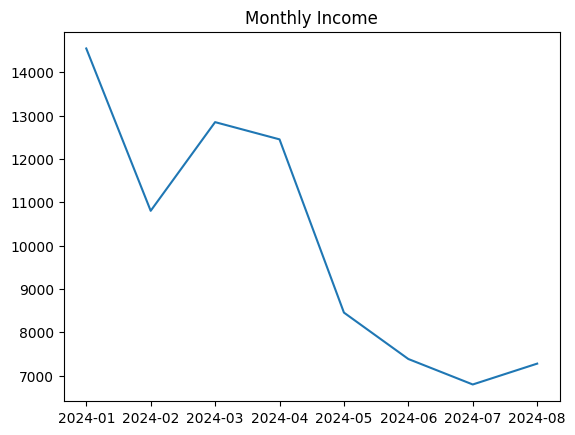

In [5]:
fig, ax = plt.subplots()
df["Month"] = df["Date"].dt.to_period("M")
revenue_month = df.groupby("Month")["Total Revenue"].sum()
ax.plot(revenue_month.index.astype(str), revenue_month.values)
ax.set_title("Monthly Income")

From the "Revenue per Month" diagram, it can be seen that revenue decreased from January to July 2024, after which it experienced a slight increase in August.

Text(0.5, 1.0, 'Income per Region')

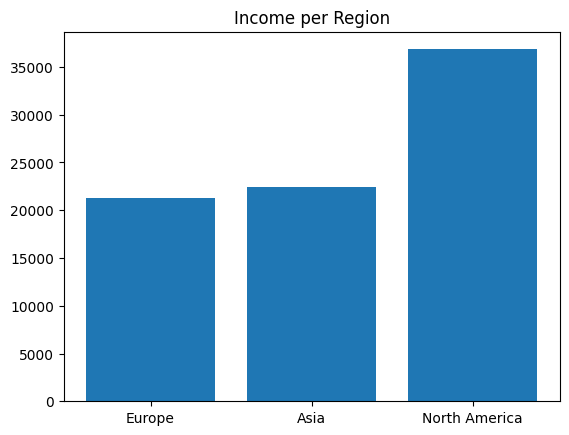

In [6]:
fig, ax = plt.subplots()
revenue_region = df.groupby("Region")["Total Revenue"].sum().sort_values()
ax.bar(revenue_region.index, revenue_region.values) 
ax.set_title("Income per Region")

The "Revenue per Region" diagram shows that the largest total income comes from North America, far compared to Asia and Europe, then Asia and Europe are not much different with Asia being less.

Text(0.5, 1.0, 'Revenue per Category')

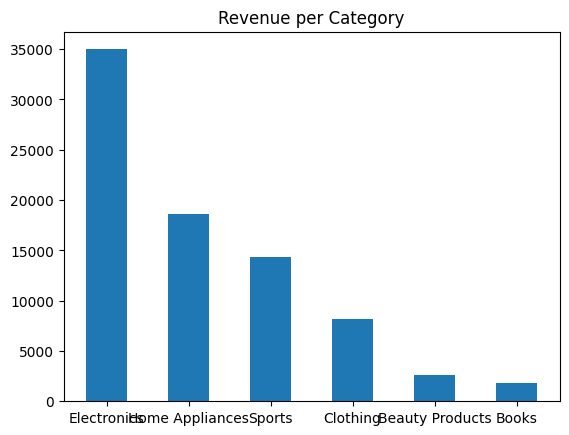

In [7]:
fig, ax = plt.subplots()
revenue_category = df.groupby("Product Category")["Total Revenue"].sum().sort_values(ascending=False)
ax.bar(revenue_category.index, revenue_category.values, width=0.5)
ax.set_title("Revenue per Category")

From the "Revenue per Category" chart, Electronics far outperforms the other categories, nearly double that of Home Appliances. Books is the lowest-ranking category, followed by Beauty Products, with similar revenues.

**Link dashboard**

https://public.tableau.com/app/profile/nicholas.calvin7573/viz/P0M1_nicholas_calvin/Dashboard1?publish=yes

**Data Statistic**

In [8]:
for category in df["Product Category"].unique():
    data = df[df["Product Category"] == category]["Total Revenue"]
    print(category)
    print(f"Mean - {data.mean()}")
    print(f"Median - {data.median()}")
    print(f"Std Dev - {data.std()}")
    print(f"Min - {data.min()}")
    print(f"Max - {data.max()}")

for region in df["Region"].unique():
    data = df[df["Region"] == region]["Total Revenue"]
    print(region)
    print(f"Mean - {data.mean()}")
    print(f"Median - {data.median()}")
    print(f"Std Dev - {data.std()}")
    print(f"Min - {data.min()}")
    print(f"Max - {data.max()}")

for payment in df["Payment Method"].unique():
    data = df[df["Payment Method"] == payment]["Total Revenue"]
    print(payment)
    print(f"Mean - {data.mean()}")
    print(f"Median - {data.median()}")
    print(f"Std Dev - {data.std()}")
    print(f"Min - {data.min()}")
    print(f"Max - {data.max()}")

q1 = df["Total Revenue"].quantile(0.25)
q2 = df["Total Revenue"].quantile(0.75)
iqr = q2 - q1
low_bound = q1 - 1.5 * iqr
up_bound = q2 + 1.5 * iqr
outliers = df[(df["Total Revenue"] < low_bound) | (df["Total Revenue"] > up_bound)]

print(f"Total Outlier : {len(outliers)}")

Electronics
Mean - 874.5602499999999
Median - 674.985
Std Dev - 784.8898465569172
Min - 99.99
Max - 3899.99
Home Appliances
Mean - 466.154
Median - 388.995
Std Dev - 462.80382861257914
Min - 89.99
Max - 2599.98
Clothing
Mean - 203.22325
Median - 179.97
Std Dev - 117.24645334721218
Min - 39.6
Max - 539.94
Books
Mean - 46.54825
Median - 38.474999999999994
Std Dev - 25.189552768039494
Min - 17.98
Max - 130.0
Beauty Products
Mean - 65.5475
Median - 50.995000000000005
Std Dev - 67.03446322792784
Min - 6.5
Max - 399.99
Sports
Mean - 358.163
Median - 259.98
Std Dev - 320.6002083368647
Min - 59.98
Max - 1895.0
North America
Mean - 460.55424999999997
Median - 118.985
Std Dev - 691.3832607827366
Min - 17.98
Max - 3899.99
Europe
Mean - 265.85074999999995
Median - 115.0
Std Dev - 385.4681598001105
Min - 6.5
Max - 2599.98
Asia
Mean - 280.693125
Median - 214.975
Std Dev - 252.20155377809522
Min - 39.6
Max - 1895.0
Credit Card
Mean - 426.42383333333333
Median - 214.975
Std Dev - 594.4492683320219
Min

The `Electronics` category has the highest average income of **874.56** and a standard deviation of **784.89**, indicating that the price variation of electronic products varies greatly from **99.99** to **3,899**. In second place is `Home Appliances` with an average of **466.15**, then there are `Sports` **358.16**, `Clothing` **203.22**, `Beauty Products` **65.55**, and finally there are `Books` **46.55**. The huge gap between Electronics and Books shows that equalizing sales between categories is still a major challenge that needs to be overcome.

The `North America` region dominates with a mean revenue of **460.55**, with a standard deviation of **691.38** showing a large mean-median difference of **460.55-118.98**, indicating that revenue in North America is heavily driven by high-value transactions from the `Electronics` category. Asia and Europe have lower means but more stable distributions, with `Asia` **280.69** slightly higher than `Europe` **265.85**.

`Credit Card` produces a mean income of **426.42** with the largest standard deviation of **594.45**, which indicates that high-value transactions such as `Electronics` are mostly made using Credit Cards. `PayPal` is at **265.85** and `Debit Card` is the lowest at **203.22**. This indicates that Debit Card users more often make transactions with smaller nominal amounts than Credit Cards.

Chi-Square is effective for testing the relationship between two categorical variables. In this dataset, `Category`, `Region`, and `Payment Method` are categorical.

**Hypothesis**

1. H0: There is no relationship between category and region.
2. H1: There is a relationship between category and region.

In [9]:
chi = pd.crosstab(df["Product Category"], df["Region"])
print(chi)
chi2, p_value, dof, expected = chi2_contingency(chi)
print(f"\nChi-Square Statistic {chi2}")
print(f"P-value {p_value}")
print(f"Degree of Freedom {dof}")

Region            Asia  Europe  North America
Product Category                             
Beauty Products      0      40              0
Books                0       0             40
Clothing            40       0              0
Electronics          0       0             40
Home Appliances      0      40              0
Sports              40       0              0

Chi-Square Statistic 479.9999999999999
P-value 8.264686477910646e-97
Degree of Freedom 10


H1 wins because the *p-value* is far from 0.05. This means that the test results indicate a relationship between category and region.